In [ ]:
from functions import *

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
coco_model = get_model(
    'coco',
    0.001,
    False,
    0
)

NameError: name 'get_model' is not defined

In [ ]:
sup_model = get_model(    
    'sup',
    0.001,
    False,
    0
)

2025-05-06 13:29:12 - minerva - INFO - No model loaded!


In [ ]:
sup_state_dict = sup_model.state_dict()
coco_state_dict = coco_model.state_dict()

sup_keys = set(sup_state_dict)
coco_keys = set(coco_state_dict)

common_keys = sup_keys & coco_keys
common_keys

{'fc.0.convs.0.0.weight',
 'fc.0.convs.0.1.bias',
 'fc.0.convs.0.1.num_batches_tracked',
 'fc.0.convs.0.1.running_mean',
 'fc.0.convs.0.1.running_var',
 'fc.0.convs.0.1.weight',
 'fc.0.convs.1.0.weight',
 'fc.0.convs.1.1.bias',
 'fc.0.convs.1.1.num_batches_tracked',
 'fc.0.convs.1.1.running_mean',
 'fc.0.convs.1.1.running_var',
 'fc.0.convs.1.1.weight',
 'fc.0.convs.2.0.weight',
 'fc.0.convs.2.1.bias',
 'fc.0.convs.2.1.num_batches_tracked',
 'fc.0.convs.2.1.running_mean',
 'fc.0.convs.2.1.running_var',
 'fc.0.convs.2.1.weight',
 'fc.0.convs.3.0.weight',
 'fc.0.convs.3.1.bias',
 'fc.0.convs.3.1.num_batches_tracked',
 'fc.0.convs.3.1.running_mean',
 'fc.0.convs.3.1.running_var',
 'fc.0.convs.3.1.weight',
 'fc.0.convs.4.1.weight',
 'fc.0.convs.4.2.bias',
 'fc.0.convs.4.2.num_batches_tracked',
 'fc.0.convs.4.2.running_mean',
 'fc.0.convs.4.2.running_var',
 'fc.0.convs.4.2.weight',
 'fc.0.project.0.weight',
 'fc.0.project.1.bias',
 'fc.0.project.1.num_batches_tracked',
 'fc.0.project.1.runn

In [ ]:
sup_keys - coco_keys

{'backbone.RN50model.bn1.bias',
 'backbone.RN50model.bn1.num_batches_tracked',
 'backbone.RN50model.bn1.running_mean',
 'backbone.RN50model.bn1.running_var',
 'backbone.RN50model.bn1.weight',
 'backbone.RN50model.conv1.weight',
 'backbone.RN50model.fc.bias',
 'backbone.RN50model.fc.weight',
 'backbone.RN50model.layer1.0.bn1.bias',
 'backbone.RN50model.layer1.0.bn1.num_batches_tracked',
 'backbone.RN50model.layer1.0.bn1.running_mean',
 'backbone.RN50model.layer1.0.bn1.running_var',
 'backbone.RN50model.layer1.0.bn1.weight',
 'backbone.RN50model.layer1.0.bn2.bias',
 'backbone.RN50model.layer1.0.bn2.num_batches_tracked',
 'backbone.RN50model.layer1.0.bn2.running_mean',
 'backbone.RN50model.layer1.0.bn2.running_var',
 'backbone.RN50model.layer1.0.bn2.weight',
 'backbone.RN50model.layer1.0.bn3.bias',
 'backbone.RN50model.layer1.0.bn3.num_batches_tracked',
 'backbone.RN50model.layer1.0.bn3.running_mean',
 'backbone.RN50model.layer1.0.bn3.running_var',
 'backbone.RN50model.layer1.0.bn3.weight

In [ ]:
coco_keys - sup_keys

{'backbone.bn1.bias',
 'backbone.bn1.num_batches_tracked',
 'backbone.bn1.running_mean',
 'backbone.bn1.running_var',
 'backbone.bn1.weight',
 'backbone.conv1.weight',
 'backbone.layer1.0.bn1.bias',
 'backbone.layer1.0.bn1.num_batches_tracked',
 'backbone.layer1.0.bn1.running_mean',
 'backbone.layer1.0.bn1.running_var',
 'backbone.layer1.0.bn1.weight',
 'backbone.layer1.0.bn2.bias',
 'backbone.layer1.0.bn2.num_batches_tracked',
 'backbone.layer1.0.bn2.running_mean',
 'backbone.layer1.0.bn2.running_var',
 'backbone.layer1.0.bn2.weight',
 'backbone.layer1.0.bn3.bias',
 'backbone.layer1.0.bn3.num_batches_tracked',
 'backbone.layer1.0.bn3.running_mean',
 'backbone.layer1.0.bn3.running_var',
 'backbone.layer1.0.bn3.weight',
 'backbone.layer1.0.conv1.weight',
 'backbone.layer1.0.conv2.weight',
 'backbone.layer1.0.conv3.weight',
 'backbone.layer1.0.downsample.0.weight',
 'backbone.layer1.0.downsample.1.bias',
 'backbone.layer1.0.downsample.1.num_batches_tracked',
 'backbone.layer1.0.downsampl

In [ ]:
import numpy as np
from pathlib import Path

from functions import *

from minerva.transforms.transform import *
from minerva.transforms.random_transform import *

from minerva.data.readers import TiffReader, NumpyArrayReader
from minerva.data.datasets import SimpleDataset
from minerva.data.data_modules import MinervaDataModule

from minerva.models.ssl.byol import BYOL
from minerva.models.nets.image.deeplabv3 import DeepLabV3Backbone

from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from lightning.pytorch.loggers.csv_logs import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

In [ ]:
input_size = (256, 256)
dataset_name = 'f3'
batch_size = 8
num_epochs = 20
repetition = 0
learning_rate = 0.001
# data_path = "/workspaces/shared_data/seismic/f3_segmentation_N"

# data_path = "/workspaces/shared_data/seismic/f3_segmentation"

# data_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai"

data_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai_N"
ckpt_path = None
log_path = None
gpus = [0]

In [ ]:
random_flip = RandomFlip(possible_axis=[1])
random_crop = RandomCrop(crop_size=input_size)
random_rotation = RandomRotation(degrees=25, prob=0.2)
transpose_to_HWC = Transpose([1, 2, 0])
transpose_to_CHW = Transpose([2, 0, 1])    
cast_to_tensor = CastTo(dtype=np.float32)
repeat = Repeat(axis=2, n_repetitions=3)

In [ ]:
byol_transform_pipeline = TransformPipeline([
    random_crop,
    random_flip,
    random_rotation,
    transpose_to_CHW,
    cast_to_tensor,
])

constrastive_transform = ContrastiveTransform(byol_transform_pipeline)

In [ ]:
train_img_reader = TiffReader(path=data_path)

pretrain_dataset = SimpleDataset(
    readers=train_img_reader,
    transforms=constrastive_transform,
    return_single=True
)

data_module = MinervaDataModule(
    train_dataset=pretrain_dataset,
    batch_size=batch_size,
    drop_last=True,
    shuffle_train=True,
    name=dataset_name
)

In [ ]:
loader = data_module.train_dataloader()
batch = next(iter(loader))
len(batch)

2

In [ ]:
batch[0][0].shape

torch.Size([3, 256, 256])

In [ ]:
batch[1][0].shape

torch.Size([3, 256, 256])

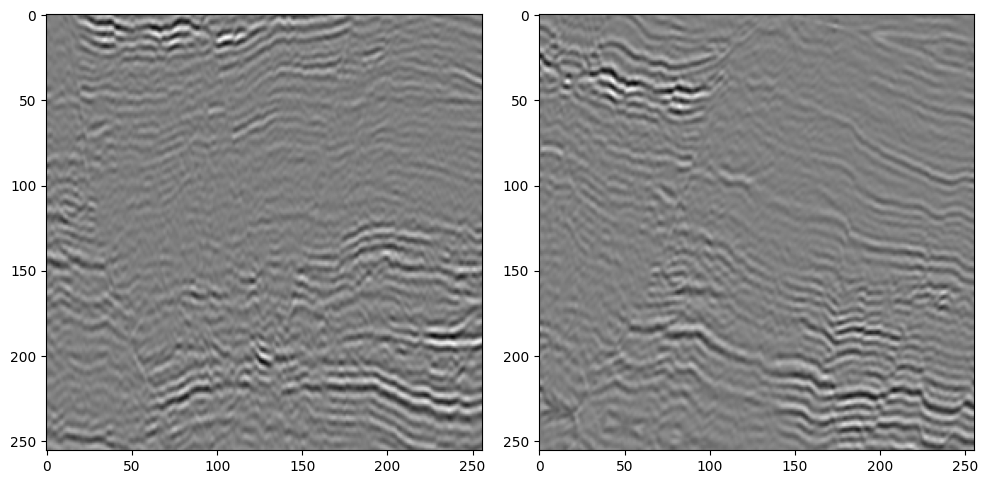

In [ ]:
plot_images([
    batch[0][4][0],
    batch[1][4][0]],
    filename="outputs/images"
            )

In [11]:
import torchvision.models.segmentation as models
import torch
import torchvision
from torchvision.models.resnet import resnet50
import torch.nn as nn



In [19]:
state_dict1 = torch.hub.load("pytorch/vision:v0.10.0", "deeplabv3_resnet50", pretrained=True).backbone.state_dict()
state_dict2 = models.deeplabv3_resnet50(weights="COCO_WITH_VOC_LABELS_V1").backbone.state_dict()

for k1, k2 in zip(state_dict1.values(), state_dict2.values()):
    if not torch.allclose(k1, k2, atol=1e-7):
        print("❌ Difference found")
        break
else:
    print("✅ Weights are identical")


Using cache found in /home/vscode/.cache/torch/hub/pytorch_vision_v0.10.0
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Weights are identical


In [18]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone_2 = resnet50(
    replace_stride_with_dilation=[False, True, True], weights=weights
)
state_dict1 = backbone_2.state_dict()

weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
backbone_1 = resnet50(
    replace_stride_with_dilation=[False, True, True], weights=weights
)

state_dict2 = backbone_2.state_dict()


for k1, k2 in zip(state_dict1.values(), state_dict2.values()):
    if not torch.allclose(k1, k2, atol=1e-7):
        print("❌ Difference found")
        break
else:
    print("✅ Weights are identical")

✅ Weights are identical


In [21]:
from functions import *

In [24]:
sup_model = get_model(    
    'sup',
    0.001,
    False,
    0
)
sup_state_dict = sup_model.state_dict()

2025-05-07 16:41:36 - minerva - INFO - No model loaded!


In [35]:
imagenet_model = get_model(
    'imagenet',
    0.001,
    False,
    0    
)
imagenet_state_dict = imagenet_model.state_dict()

2025-05-07 16:58:13 - minerva - INFO - IMAGENET backbone loaded


In [25]:
coco_model = get_model(
    'coco',
    0.001,
    False,
    0
)
coco_state_dict = coco_model.state_dict()

Using cache found in /home/vscode/.cache/torch/hub/pytorch_vision_v0.10.0
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
2025-05-07 16:41:39 - minerva - INFO - COCO backbone loaded


In [36]:
f3_model = get_model(
    'f3', 
    0.001,
    False,
    0
)
f3_state_dict = f3_model.state_dict()

2025-05-07 16:58:15 - minerva - INFO - f3 backbone loaded


Model loaded from ckpt/pretrain/0/V0_pretrain_f3_In256_B32_E500/f3/last.ckpt


In [ ]:
for key in sup_state_dict.keys() & coco_state_dict.keys():
    if not torch.allclose(sup_state_dict[key], coco_state_dict[key], atol=1e-7):
        print(f"❌ Difference found in key: {key}")
        print(f"sup_state_dict[{key}]: {sup_state_dict[key].name}")
        print(f"coco_state_dict[{key}]: {coco_state_dict[key].name}")
    # else:
    #     print("✅ All matching keys have identical values")

In [52]:
import torch

def compare_model_layers(state_dict1, state_dict2, atol=1e-7):
    """
    Compare two model state dictionaries and print differences in layers, independent of their names.

    Args:
        state_dict1 (OrderedDict): State dictionary of the first model.
        state_dict2 (OrderedDict): State dictionary of the second model.
        atol (float): Absolute tolerance for comparison.

    Returns:
        None
    """
    layers1 = list(state_dict1.values())
    layers2 = list(state_dict2.values())

    min_len = min(len(layers1), len(layers2))

    for i in range(min_len):
        if not torch.allclose(layers1[i], layers2[i], atol=atol):
            print(f"❌ Difference found in layer {i}")
            print(f"Layer {i} in model 1: {layers1[i].shape}")
            print(f"Layer {i} in model 2: {layers2[i].shape}")
            return

    if len(layers1) > len(layers2):
        print(f"Model 1 has {len(layers1) - len(layers2)} extra layers.")
    elif len(layers2) > len(layers1):
        print(f"Model 2 has {len(layers2) - len(layers1)} extra layers.")
    else:
        print("✅ All layers match within the given tolerance.")

# Example usage:
compare_model_layers(sup_state_dict, coco_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [53]:
compare_model_layers(sup_state_dict, f3_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [54]:
compare_model_layers(f3_state_dict, imagenet_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [55]:
compare_model_layers(coco_state_dict, imagenet_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])
